In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [2]:
os_ANN = xr.open_dataset('/scratch/db194/mom6/dec2025/DoubleGyre/test_ANN/OUTPUT/ocean.stats.nc', decode_times=False)
os_ANN_bfilt = xr.open_dataset('/scratch/db194/mom6/dec2025/DoubleGyre/test_ANN_boundary_filter/OUTPUT/ocean.stats.nc', decode_times=False)
os_noANN = xr.open_dataset('/scratch/db194/mom6/dec2025/DoubleGyre/test_noANN/OUTPUT/ocean.stats.nc', decode_times=False)

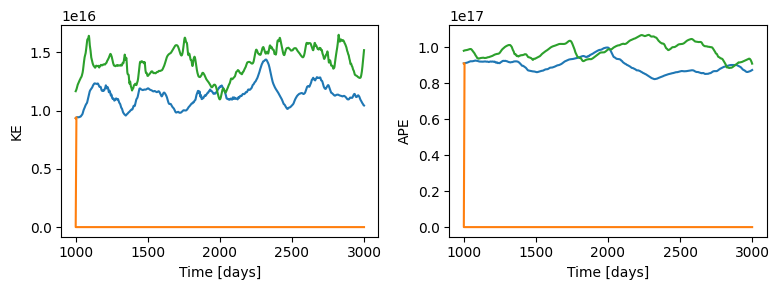

In [3]:
plt.figure(figsize=(8,3))


plt.subplot(121)
os_ANN.KE.sum('Layer').plot()
os_ANN_bfilt.KE.sum('Layer').plot()
os_noANN.KE.sum('Layer').plot()

plt.subplot(122)
os_ANN.APE.sum('Interface').plot()
os_ANN_bfilt.APE.sum('Interface').plot()
os_noANN.APE.sum('Interface').plot()

plt.tight_layout()

In [4]:
ds_ANN = xr.open_mfdataset('/home/db194/scratch_db194/mom6/dec2025/DoubleGyre/test_ANN/OUTPUT/prog_0*.nc', decode_times=False)


In [5]:
ds_ANN

<xarray.Dataset> Size: 2GB
Dimensions:         (Time: 600, zl: 2, yh: 100, xq: 111, yq: 101, xh: 110, zi: 3)
Coordinates:
  * xq              (xq) float64 888B 0.0 0.2 0.4 0.6 ... 21.4 21.6 21.8 22.0
  * yh              (yh) float64 800B 30.1 30.3 30.5 30.7 ... 49.5 49.7 49.9
  * zl              (zl) float64 16B 1.035e+03 1.036e+03
  * Time            (Time) float64 5kB 5.0 10.0 15.0 ... 2.995e+03 3e+03
  * xh              (xh) float64 880B 0.1 0.3 0.5 0.7 ... 21.3 21.5 21.7 21.9
  * yq              (yq) float64 808B 30.0 30.2 30.4 30.6 ... 49.6 49.8 50.0
  * zi              (zi) float64 24B 1.034e+03 1.036e+03 1.037e+03
Data variables: (12/14)
    u               (Time, zl, yh, xq) float64 107MB dask.array<chunksize=(40, 2, 100, 111), meta=np.ndarray>
    v               (Time, zl, yq, xh) float64 107MB dask.array<chunksize=(40, 2, 101, 110), meta=np.ndarray>
    h               (Time, zl, yh, xh) float64 106MB dask.array<chunksize=(40, 2, 100, 110), meta=np.ndarray>
    e               (Time, zi, yh, xh) float64 158MB dask.array<chunksize=(40, 3, 100, 110), meta=np.ndarray>
    RV              (Time, zl, yq, xq) float64 108MB dask.array<chunksize=(40, 2, 101, 111), meta=np.ndarray>
    PV              (Time, zl, yq, xq) float64 108MB dask.array<chunksize=(40, 2, 101, 111), meta=np.ndarray>
    ...              ...
    GM_sfn_x        (Time, zi, yh, xq) float64 160MB dask.array<chunksize=(40, 3, 100, 111), meta=np.ndarray>
    GM_sfn_y        (Time, zi, yq, xh) float64 160MB dask.array<chunksize=(40, 3, 101, 110), meta=np.ndarray>
    uh              (Time, zl, yh, xq) float64 107MB dask.array<chunksize=(40, 2, 100, 111), meta=np.ndarray>
    vh              (Time, zl, yq, xh) float64 107MB dask.array<chunksize=(40, 2, 101, 110), meta=np.ndarray>
    uhGM            (Time, zl, yh, xq) float64 107MB dask.array<chunksize=(40, 2, 100, 111), meta=np.ndarray>
    vhGM            (Time, zl, yq, xh) float64 107MB dask.array<chunksize=(40, 2, 101, 110), meta=np.ndarray>
Attributes:
    filename:   prog_00005.nc
    title:      Phillips experiment
    grid_type:  regular
    grid_tile:  N/A

In [6]:
ds_ANN_bfilt = xr.open_mfdataset('/home/db194/scratch_db194/mom6/dec2025/DoubleGyre/test_ANN_boundary_filter/OUTPUT/prog_0*.nc', decode_times=False)

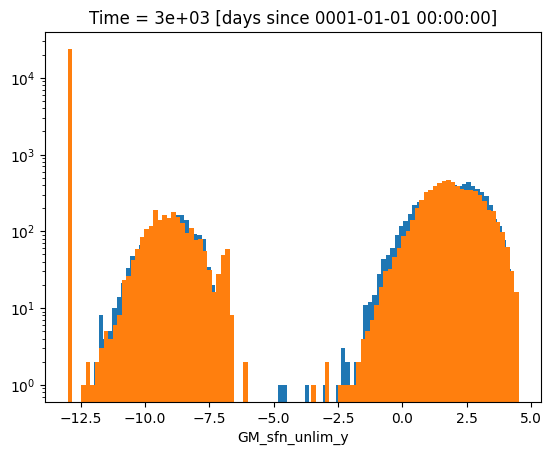

In [7]:
np.log10(np.abs(ds_ANN.GM_sfn_unlim_x)+1e-13).isel(Time=-1).plot.hist(bins=100);
np.log10(np.abs(ds_ANN.GM_sfn_unlim_y)+1e-13).isel(Time=-1).plot.hist(bins=100);
plt.yscale('log')

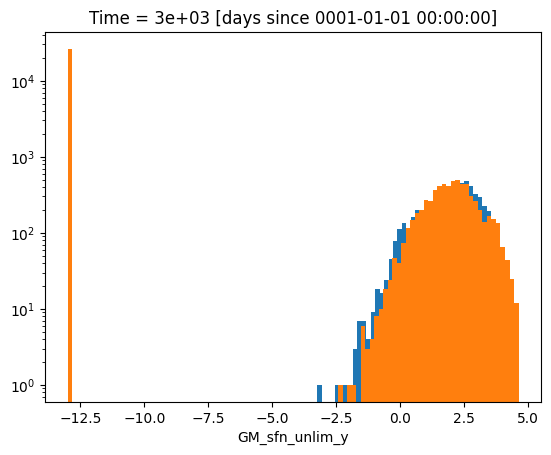

In [8]:
np.log10(np.abs(ds_ANN_bfilt.GM_sfn_unlim_x)+1e-13).isel(Time=-1).plot.hist(bins=100);
np.log10(np.abs(ds_ANN_bfilt.GM_sfn_unlim_y)+1e-13).isel(Time=-1).plot.hist(bins=100);
plt.yscale('log')

In [9]:
ds_noANN = xr.open_mfdataset('/home/db194/scratch_db194/mom6/dec2025/DoubleGyre/test_noANN/OUTPUT/prog_0*.nc', decode_times=False)


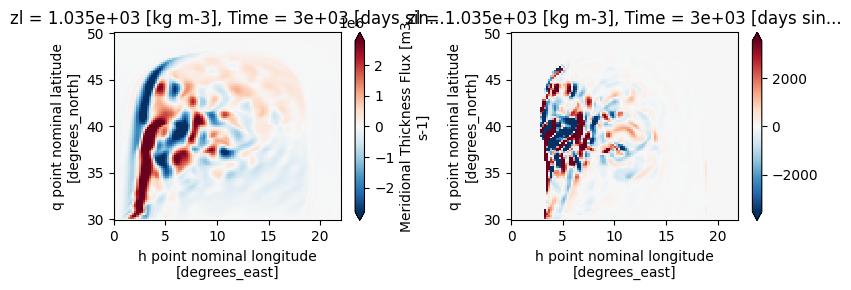

In [11]:
plt.figure(figsize=(8,3))

plt.subplot(121)
ds_ANN.vh.isel(Time=-1, zl=0).plot(robust=True)

plt.subplot(122)
(ds_ANN.vhGM / ds_ANN.zl).isel(Time=-1, zl=0).plot(robust=True)

plt.tight_layout()

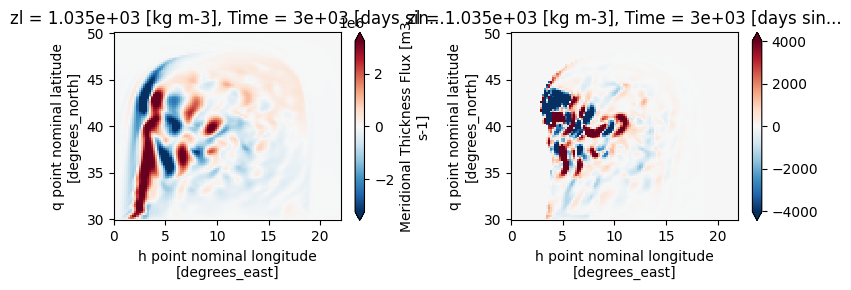

In [12]:
plt.figure(figsize=(8,3))

plt.subplot(121)
ds_ANN_bfilt.vh.isel(Time=-1, zl=0).plot(robust=True)

plt.subplot(122)
(ds_ANN_bfilt.vhGM / ds_ANN_bfilt.zl).isel(Time=-1, zl=0).plot(robust=True)

plt.tight_layout()

In [13]:
ds_ANN_old = xr.open_mfdataset('/home/db194/scratch_db194/mom6/base_experiments_2025/DoubleGyre/31Mar/runs/res_20km_ANN_0.75/OUTPUT/prog_0*.nc', decode_times=False)


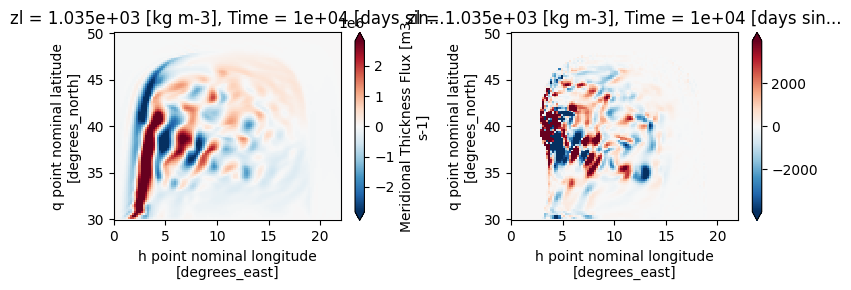

In [14]:
plt.figure(figsize=(8,3))

plt.subplot(121)
ds_ANN_old.vh.isel(Time=-1, zl=0).plot(robust=True)

plt.subplot(122)
(ds_ANN_old.vhGM / ds_ANN_old.zl).isel(Time=-1, zl=0).plot(robust=True)

plt.tight_layout()

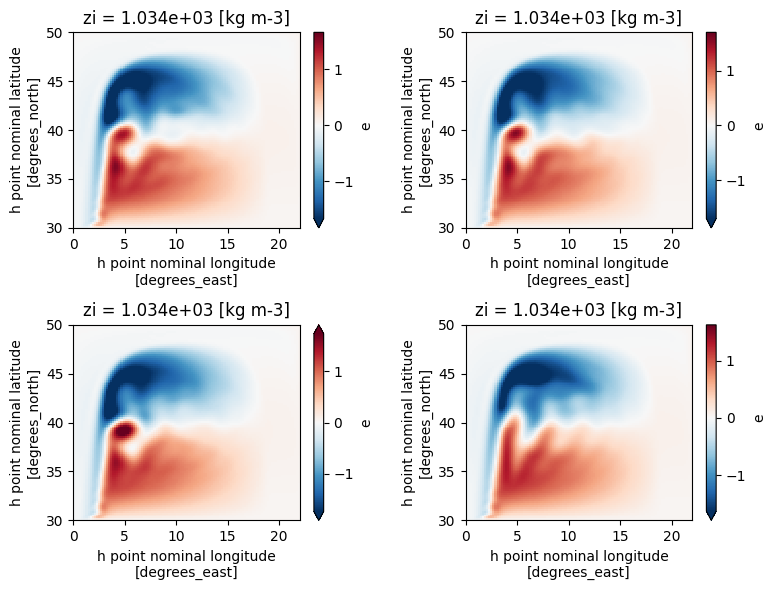

In [15]:
plt.figure(figsize=(8,6))

plt.subplot(221)
ds_ANN.e.isel(zi=0).sel(Time=slice(300, None)).mean('Time').plot(robust=True)

plt.subplot(222)
ds_ANN_bfilt.e.isel(zi=0).sel(Time=slice(300, None)).mean('Time').plot(robust=True)

plt.subplot(223)
ds_noANN.e.isel(zi=0).sel(Time=slice(300, None)).mean('Time').plot(robust=True)

plt.subplot(224)
ds_ANN_old.e.isel(zi=0).sel(Time=slice(300, 3000)).mean('Time').plot(robust=True)

plt.tight_layout()